Irrigation  High   Low
Fertilizer            
A           26.0  21.0
B           30.0  24.0
C           33.0  22.0

TWO-WAY ANOVA TABLE
                             sum_sq    df      F  PR(>F)
C(Fertilizer)                  57.0   2.0   28.5  0.0000
C(Irrigation)                 242.0   1.0  242.0  0.0000
C(Fertilizer):C(Irrigation)    31.0   2.0   15.5  0.0005
Residual                       12.0  12.0    NaN     NaN

C(Fertilizer)                  p = 0.000028 -> Significant (Reject H0)
C(Irrigation)                  p = 0.000000 -> Significant (Reject H0)
C(Fertilizer):C(Irrigation)    p = 0.000472 -> Significant (Reject H0)


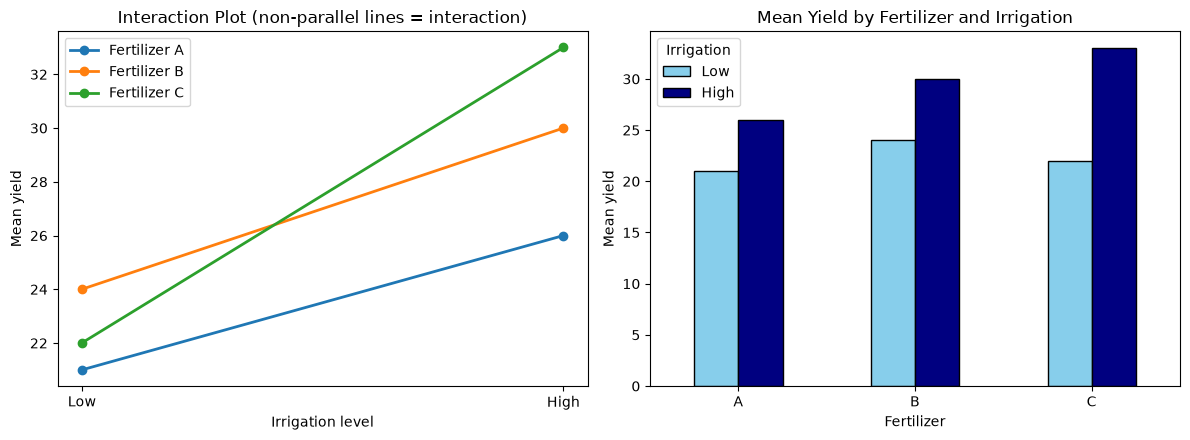

In [3]:
import pandas as pd   
import matplotlib.pyplot as plt 
import statsmodels.api as sm 
from statsmodels.formula.api import ols 
  
# Step 1: Data in table form 
data = pd.DataFrame({ 
    'Fertilizer': ['A']*6 + ['B']*6 + ['C']*6, 
    'Irrigation': (['Low']*3 + ['High']*3) * 3, 
    'Yield': [20, 22, 21, 25, 27, 26,      # Fertilizer A 
              24, 25, 23, 30, 31, 29,      # Fertilizer B 
              22, 21, 23, 32, 33, 34]      # Fertilizer C 
}) 
print(data.pivot_table(values='Yield', index='Fertilizer', columns='Irrigation', 
aggfunc='mean').round(2)) 
alpha = 0.05 
  
# Step 2: Two-way ANOVA with interaction 
model = ols('Yield ~ C(Fertilizer) + C(Irrigation) + C(Fertilizer):C(Irrigation)', 
data=data).fit() 
anova_table = sm.stats.anova_lm(model, typ=2) 
print("\nTWO-WAY ANOVA TABLE") 
print(anova_table.round(4)) 
  
# Step 3: Decision for each factor 
print() 
for source in anova_table.index[:-1]: 
    p = anova_table.loc[source, 'PR(>F)'] 
    decision = 'Significant (Reject H0)' if p < alpha else 'Not significant (Fail to reject H0)' 
    print(f"{source:<30} p = {p:.6f} -> {decision}") 
  
# Step 4: Graphs - interaction plot and grouped bar chart 
means = data.groupby(['Fertilizer', 'Irrigation'])['Yield'].mean().unstack()[['Low', 'High']] 
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5)) 
for fert in means.index: 
    ax[0].plot(means.columns, means.loc[fert], marker='o', lw=2, label=f'Fertilizer {fert}') 
ax[0].set_title('Interaction Plot (non-parallel lines = interaction)') 
ax[0].set_xlabel('Irrigation level'); ax[0].set_ylabel('Mean yield'); ax[0].legend() 
  
means.plot(kind='bar', ax=ax[1], color=['skyblue', 'navy'], edgecolor='black', rot=0) 
ax[1].set_title('Mean Yield by Fertilizer and Irrigation') 
ax[1].set_xlabel('Fertilizer'); ax[1].set_ylabel('Mean yield') 
plt.tight_layout() 
plt.show() 